# Part 1

In [1]:
import sys
import os
import pandas as pd
import json
import spacy
import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from data_loader import load_pkl

tqdm.pandas()

nlp = spacy.load('en_core_web_sm')

In [2]:
dfs = load_pkl(root_path = "/Users/hugorameil/Desktop/Code/GitHub/NLP_project/")

## Dataframes creation

In [3]:
df_tweet = (
    dfs["Tweet"]
    .assign(created_at=lambda x: pd.to_datetime(x["created_at"].str[:10]))
)

df_event = (dfs["Event"])
df_user = (dfs["User"])
df_hashtag = (dfs["Hashtag"])
df_post_category = (dfs["PostCategory"])

Type of events : ['wildfire', 'earthquake', 'flood', 'typhoon', 'shooting', 'bombing']

In [4]:
merge = (
    df_tweet
    .merge(
        df_event,
        how="inner",
        left_on="topic",
        right_on="trecisid",
        suffixes=("_tweet", "_event"),
    )
    .assign(week_start = lambda df : df["created_at"].dt.to_period("W").dt.start_time)
)
merge.head()

#### store the csv event per weeks

In [5]:
id_event_week = (merge
.groupby(["week_start", "id_event"]).count()
.reset_index()
.set_index('week_start')
.assign(tweet_number = lambda x: x['id_tweet'])
.filter(['id_event', 'tweet_number'])
)

# id_event_week.to_csv('/Users/hugorameil/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Code/GitHub/NLP_project/data/Nodes/id_event_week.csv')

#### same job for type of events

In [6]:
toe_week = (merge
.groupby(["week_start", "eventType"]).count()
.reset_index()
.set_index('week_start')
.assign(tweet_number = lambda x: x['id_tweet'])
.filter(['eventType', 'tweet_number'])
)

#toe_week.to_csv('/Users/hugorameil/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Code/GitHub/NLP_project/data/Nodes/toe_week.csv')

# Text preprocessing

In [11]:
def preprocess_text(text):
    doc = nlp(text)
    # Tokenize, remove stopwords, punctuation, and lemmatize
    preprocessed_text = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct]
    
    return ' '.join(preprocessed_text)

In [12]:
df_tweet['cleaned_text'] = df_tweet['text'].progress_apply(preprocess_text)

100%|██████████| 55986/55986 [07:24<00:00, 126.00it/s]


# word distribution

In [13]:
word_week = (
    df_tweet
    .filter(['created_at','cleaned_text'])
    .assign(week_start = lambda df : df["created_at"].dt.to_period("W").dt.start_time)
    .filter(['week_start', 'cleaned_text'])
)
word_week.head()

,week_start,cleaned_text
0,2012-06-04,colorado tell amazing http://t.co/6z0qq7qe
1,2012-06-04,rt @northfortynews tanker helicopter head para...
2,2012-06-04,evacuation center cache la poudre middle schoo...
3,2012-06-04,20f degree cool tomorrow north central amp nor...
4,2012-06-04,fema authorize use federal fund help firefight...


In [126]:
#word_week.to_csv('/Users/hugorameil/Desktop/Code/GitHub/NLP_project/data/Nodes/word_week.csv')

In [14]:
def get_word_trend(df, word, freq='W'):
    df['contains_word'] = df['cleaned_text'].str.contains(word, case=False, na=False)
    trend = df.groupby(pd.Grouper(key='week_start', freq=freq))['contains_word'].sum().reset_index()
    return trend

<Axes: xlabel='week_start'>

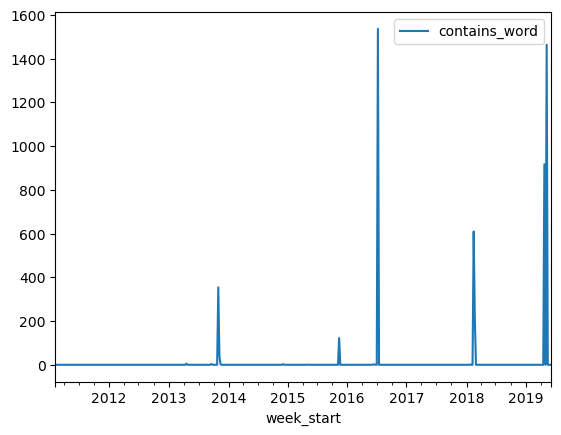

In [15]:
get_word_trend(word_week, 'shooting').plot(x='week_start', y='contains_word')

# Topics clusters

## Inverse document frequency

- We use LDA for topic modeling based on inverse document frequency.
- We want to extract 5 topics, arbitrarily.

In [145]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df_tweet['cleaned_text'])

In [148]:
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(X)

words = vectorizer.get_feature_names_out()

In [152]:
def display_topics(model, feature_names, num_words=5):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-num_words:]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

display_topics(lda_model, words)

Topic 1: hagupit, philippines, ymmfire, typhoon, http
Topic 2: paris, flood, school, shooting, https
Topic 3: dallas, help, rt, nepal, http
Topic 4: https, pray, http, safe, earthquake
Topic 5: alberta, hurricane, cyclone, mozambique, https


# Information retrieval

### word embeddings

In [21]:
def get_doc_vector(text):
    doc = nlp(text)
    return doc.vector

small model this is why we have only 96 dimensions

In [25]:
df_tweet['vector'] = df_tweet['cleaned_text'].progress_apply(get_doc_vector)

100%|██████████| 55986/55986 [05:51<00:00, 159.33it/s]


In [26]:
df_tweet_vector = (
    df_tweet
    .filter(['id','created_at', 'text', 'topic', 'vector'])
)

df_tweet_vector.head()

,id,created_at,text,topic,vector
0,211281973870727170,2012-06-09,#colorado. Told you its #amazing http://t.co/6...,TRECIS-CTIT-H-001,"[0.059432246, -0.6954141, 0.09215418, -0.07683..."
1,211557401231495171,2012-06-09,RT @northfortynews: Tanker helicopter heads up...,TRECIS-CTIT-H-001,"[0.09128665, -0.5260597, 0.3576186, 0.45029697..."
2,211565974422425600,2012-06-09,#Evacuation center Cache La Poudre Middle Scho...,TRECIS-CTIT-H-001,"[0.15135014, -0.5267405, 0.20749299, 0.2416165..."
3,211607187653533697,2012-06-09,20F degrees cooler tomorrow in North Central &...,TRECIS-CTIT-H-001,"[0.22207415, -0.40042835, -0.03280258, -0.1272..."
4,211654415503990784,2012-06-10,FEMA has authorized the use of federal funds t...,TRECIS-CTIT-H-001,"[0.0051706163, -0.72611034, 0.039333627, 0.312..."


We then store df_tweet_vector as a .pkl file

In [37]:
#save_path = "/Users/hugorameil/Desktop/Code/GitHub/NLP_project/data/Nodes/tweet_vectors.pkl"
#os.makedirs(os.path.dirname(save_path), exist_ok=True)

#with open(save_path, "wb") as f:
#    pickle.dump(df_tweet_vector, f)

#print(f"Data saved to {save_path}")

Data saved to /Users/hugorameil/Desktop/Code/GitHub/NLP_project/data/Nodes/tweet_vectors.pkl


## Similarity computation

In [19]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    return dot_product / (norm_vec1 * norm_vec2)

def get_top_k_tweets(df, query_vector, k: int=5):
    df['cosine_similarity'] = df['vector'].apply(lambda x: cosine_similarity(query_vector, x))
    df = df.sort_values(by='cosine_similarity', ascending=False)
    top_k_tweets = df.filter(['id', 'text', 'cosine_similarity']).head(k)
    
    return top_k_tweets

## IR pipeline

In [18]:
def IR(query, k: int=5):
    cleaned_query = preprocess_text(query)
    vector_query = get_doc_vector(cleaned_query)
    top_k_tweets = get_top_k_tweets(df_tweet_vector, vector_query, k)
    
    return top_k_tweets

# Information Retrieval (examples)  

### User queries

In [16]:
query_1 = "ColorAdo, wilDfires" 
query_2 = "SHooting .in Las Vegas,"
query_3 = "BombinG in Boston/:"

In [52]:
IR(query_1)

,id,text,cosine_similarity
21138,592912357908750336,"India?s help to Nepal terrific, but don?t crow...",0.713943
18606,592666191870750720,Seems Legit! #Chutiya https://t.co/M2Cg7qMRQN,0.700903
30285,751148330294456321,Dallas please help me out. Withe all the shoot...,0.700713
6851,369887180518211584,RT @JohnLloydCruzTM: RT @sharon_cuneta12: Than...,0.697664
54119,369858485292244992,RT @sharon_cuneta12: Thanks! RT @theGEEKchic: ...,0.691867


In [53]:
IR(query_2, 5)

In [51]:
IR(query_3, 1)

,id,text,cosine_similarity
42773,1125878942026616835,"school shooting in Colorado, 2 injured",0.632135


# End of part 1